In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [3]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [4]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [6]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*len(c2)
    train_texts_aug = train_texts.tolist() + c2['augmented-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [8]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions

In [7]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# Температура 0.0

In [9]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_0_0.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.015500,0.942776
2,0.518300,1.015001
3,0.131300,1.466750


Обучение завершено за 320.87 секунд (0:05:20)


In [10]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6253
F1 Micro: 0.6253
F1 Macro: 0.6029
F1 Weighted: 0.6240
MAE: 0.4389
              precision    recall  f1-score   support

           1       0.88      0.49      0.63       153
           2       0.53      0.73      0.61       227
           3       0.62      0.70      0.66       475
           4       0.62      0.58      0.60       343
           5       0.69      0.57      0.62       237
           6       1.00      0.33      0.50        30

    accuracy                           0.63      1465
   macro avg       0.72      0.57      0.60      1465
weighted avg       0.65      0.63      0.62      1465



0.6253
0.6253
0.6029
0.6240
0.4389
320.87


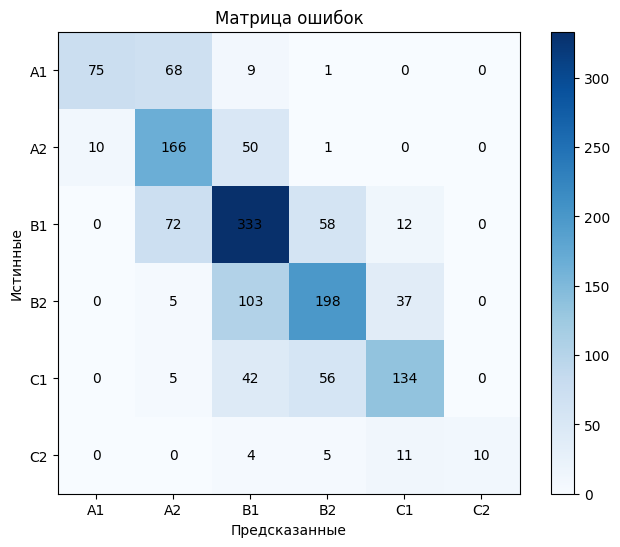

In [11]:
visualize_cm(true_labels, predictions)

# Температура 0.1

In [12]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_0_1.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.025400,0.947726
2,0.523200,0.994412
3,0.134000,1.414766


Обучение завершено за 326.98 секунд (0:05:26)


In [13]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6164
F1 Micro: 0.6164
F1 Macro: 0.5731
F1 Weighted: 0.6133
MAE: 0.4539
              precision    recall  f1-score   support

           1       0.89      0.46      0.60       153
           2       0.51      0.73      0.60       227
           3       0.61      0.70      0.65       475
           4       0.64      0.55      0.59       343
           5       0.64      0.58      0.61       237
           6       1.00      0.23      0.38        30

    accuracy                           0.62      1465
   macro avg       0.71      0.54      0.57      1465
weighted avg       0.64      0.62      0.61      1465



0.6164
0.6164
0.5731
0.6133
0.4539
326.98


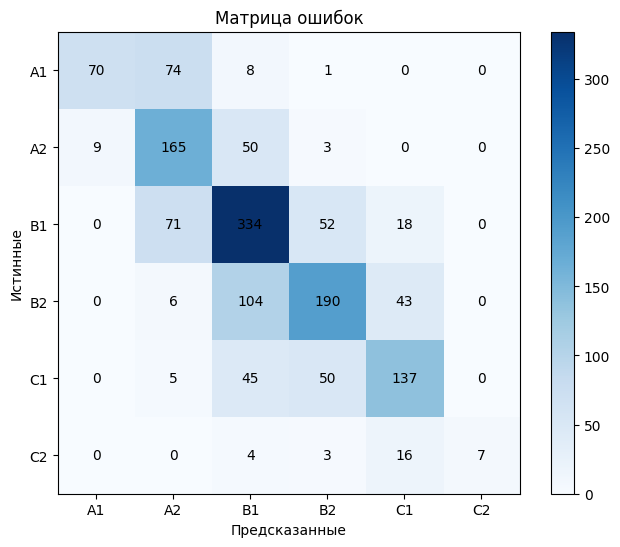

In [14]:
visualize_cm(true_labels, predictions)

# Температура 0.2

In [15]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_0_2.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.039200,0.939606
2,0.528100,0.993117
3,0.123200,1.422371


Обучение завершено за 327.15 секунд (0:05:27)


In [16]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6225
F1 Micro: 0.6225
F1 Macro: 0.5935
F1 Weighted: 0.6206
MAE: 0.4444
              precision    recall  f1-score   support

           1       0.89      0.47      0.62       153
           2       0.53      0.73      0.61       227
           3       0.62      0.69      0.65       475
           4       0.62      0.57      0.59       343
           5       0.65      0.60      0.63       237
           6       1.00      0.30      0.46        30

    accuracy                           0.62      1465
   macro avg       0.72      0.56      0.59      1465
weighted avg       0.65      0.62      0.62      1465



0.6225
0.6225
0.5935
0.6206
0.4444
327.15


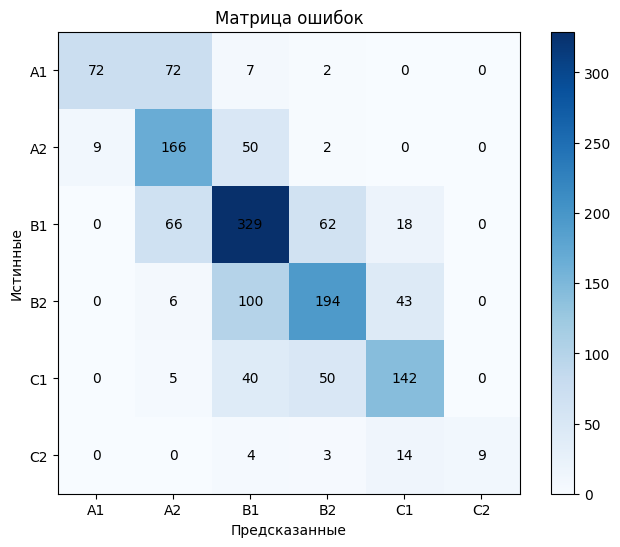

In [17]:
visualize_cm(true_labels, predictions)

# Температура 0.4

In [9]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_0_4.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.042500,0.926381
2,0.516000,0.976212
3,0.149900,1.376782


Обучение завершено за 385.75 секунд (0:06:25)


In [10]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6341
F1 Micro: 0.6341
F1 Macro: 0.5927
F1 Weighted: 0.6305
MAE: 0.4410
              precision    recall  f1-score   support

           1       0.87      0.58      0.69       153
           2       0.55      0.72      0.62       227
           3       0.62      0.75      0.68       475
           4       0.65      0.54      0.59       343
           5       0.65      0.55      0.59       237
           6       1.00      0.23      0.38        30

    accuracy                           0.63      1465
   macro avg       0.72      0.56      0.59      1465
weighted avg       0.65      0.63      0.63      1465



0.6341
0.6341
0.5927
0.6305
0.4410
385.75


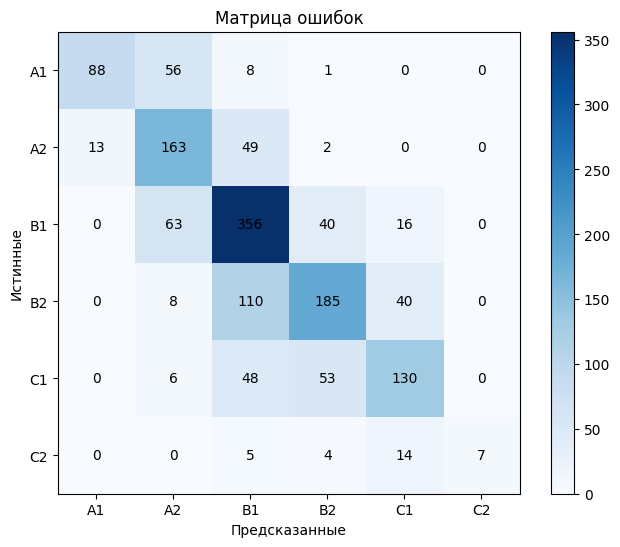

In [11]:
visualize_cm(true_labels, predictions)

# Температура 0.5

In [12]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_0_5.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.041900,0.929251
2,0.519100,1.005840
3,0.132300,1.415930


Обучение завершено за 382.09 секунд (0:06:22)


In [13]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6300
F1 Micro: 0.6300
F1 Macro: 0.6026
F1 Weighted: 0.6284
MAE: 0.4396
              precision    recall  f1-score   support

           1       0.90      0.51      0.65       153
           2       0.54      0.74      0.62       227
           3       0.63      0.70      0.66       475
           4       0.63      0.56      0.60       343
           5       0.64      0.61      0.62       237
           6       1.00      0.30      0.46        30

    accuracy                           0.63      1465
   macro avg       0.72      0.57      0.60      1465
weighted avg       0.65      0.63      0.63      1465



0.6300
0.6300
0.6026
0.6284
0.4396
382.09


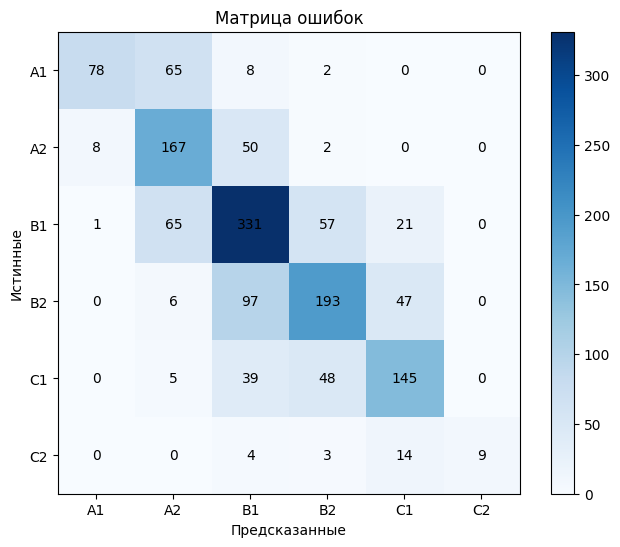

In [14]:
visualize_cm(true_labels, predictions)

# Температура 0.6

In [15]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_0_6.csv')
model, val_dataset, train_time = fit(c2)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 7912f25b-3f83-43b6-a8d7-838661a13f01)')' thrown while requesting HEAD https://huggingface.co/sberbank-ai/ruBert-large/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.035100,0.934216
2,0.521700,0.959600
3,0.134600,1.415489


Обучение завершено за 380.76 секунд (0:06:20)


In [16]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6334
F1 Micro: 0.6334
F1 Macro: 0.5964
F1 Weighted: 0.6313
MAE: 0.4382
              precision    recall  f1-score   support

           1       0.90      0.56      0.69       153
           2       0.55      0.75      0.63       227
           3       0.63      0.69      0.66       475
           4       0.64      0.55      0.59       343
           5       0.63      0.62      0.63       237
           6       1.00      0.23      0.38        30

    accuracy                           0.63      1465
   macro avg       0.72      0.57      0.60      1465
weighted avg       0.65      0.63      0.63      1465



0.6334
0.6334
0.5964
0.6313
0.4382
380.76


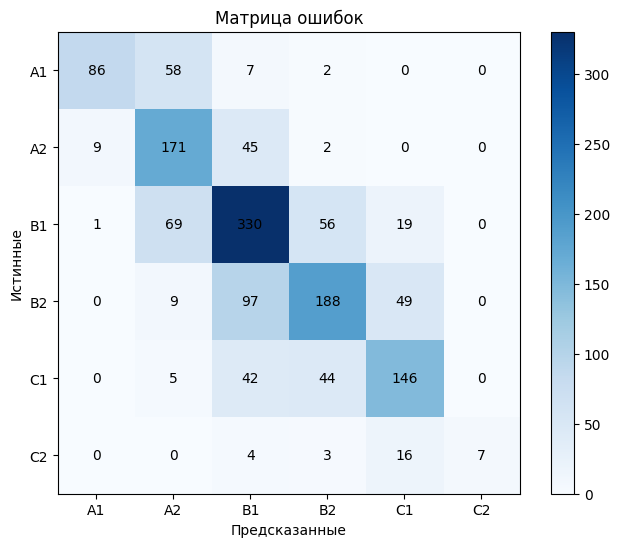

In [17]:
visualize_cm(true_labels, predictions)

# Температура 0.7

In [18]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_0_7.csv')
model, val_dataset, train_time = fit(c2)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 8dbf372c-42e9-4688-94fe-387face1cb61)')' thrown while requesting HEAD https://huggingface.co/sberbank-ai/ruBert-large/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.036300,0.939084
2,0.522600,0.999094
3,0.138900,1.444890


Обучение завершено за 382.27 секунд (0:06:22)


In [19]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6280
F1 Micro: 0.6280
F1 Macro: 0.5755
F1 Weighted: 0.6245
MAE: 0.4396
              precision    recall  f1-score   support

           1       0.90      0.46      0.61       153
           2       0.53      0.73      0.62       227
           3       0.63      0.71      0.67       475
           4       0.63      0.58      0.61       343
           5       0.64      0.59      0.62       237
           6       1.00      0.20      0.33        30

    accuracy                           0.63      1465
   macro avg       0.72      0.55      0.58      1465
weighted avg       0.65      0.63      0.62      1465



0.6280
0.6280
0.5755
0.6245
0.4396
382.27


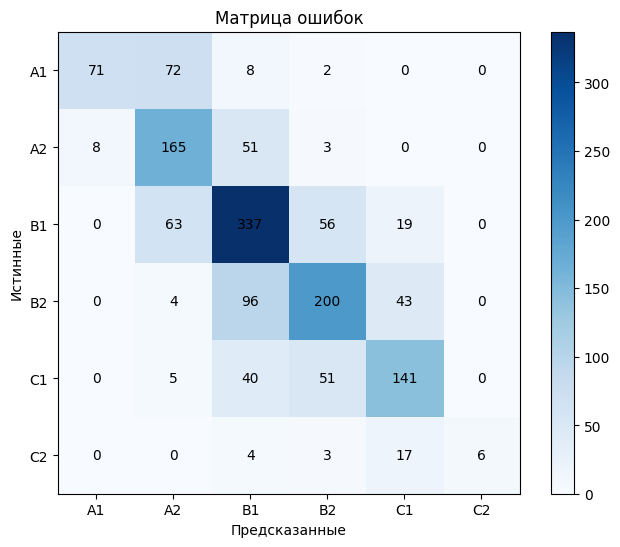

In [20]:
visualize_cm(true_labels, predictions)

# Температура 0.8

In [21]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_0_8.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.027500,0.942582
2,0.520700,1.024011
3,0.141300,1.398454


Обучение завершено за 388.37 секунд (0:06:28)


In [22]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6300
F1 Micro: 0.6300
F1 Macro: 0.5911
F1 Weighted: 0.6276
MAE: 0.4410
              precision    recall  f1-score   support

           1       0.88      0.54      0.67       153
           2       0.54      0.73      0.62       227
           3       0.61      0.71      0.66       475
           4       0.65      0.54      0.59       343
           5       0.65      0.61      0.63       237
           6       1.00      0.23      0.38        30

    accuracy                           0.63      1465
   macro avg       0.72      0.56      0.59      1465
weighted avg       0.65      0.63      0.63      1465



0.6300
0.6300
0.5911
0.6276
0.4410
388.37


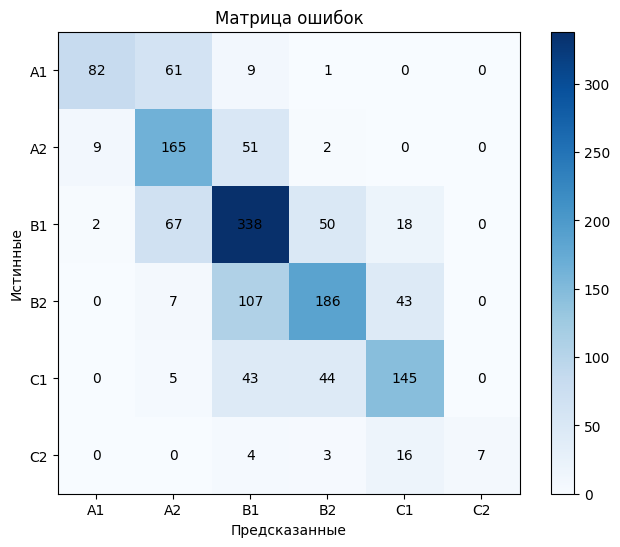

In [23]:
visualize_cm(true_labels, predictions)

# Температура 0.9

In [24]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_0_9.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.032900,0.943156
2,0.524400,1.004922
3,0.133700,1.429901


Обучение завершено за 381.66 секунд (0:06:21)


In [25]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6212
F1 Micro: 0.6212
F1 Macro: 0.5908
F1 Weighted: 0.6192
MAE: 0.4498
              precision    recall  f1-score   support

           1       0.89      0.52      0.66       153
           2       0.53      0.76      0.62       227
           3       0.62      0.68      0.65       475
           4       0.63      0.54      0.58       343
           5       0.64      0.59      0.62       237
           6       1.00      0.27      0.42        30

    accuracy                           0.62      1465
   macro avg       0.72      0.56      0.59      1465
weighted avg       0.65      0.62      0.62      1465



0.6212
0.6212
0.5908
0.6192
0.4498
381.66


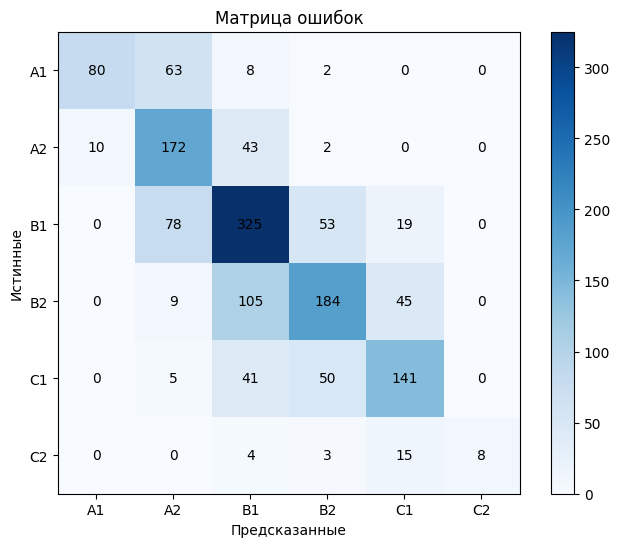

In [26]:
visualize_cm(true_labels, predictions)

# Температура 1.0

In [27]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_1_0.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.035600,0.932875
2,0.527600,0.975307
3,0.132100,1.412162


Обучение завершено за 381.89 секунд (0:06:21)


In [28]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6307
F1 Micro: 0.6307
F1 Macro: 0.5885
F1 Weighted: 0.6289
MAE: 0.4410
              precision    recall  f1-score   support

           1       0.90      0.52      0.66       153
           2       0.54      0.72      0.62       227
           3       0.63      0.69      0.66       475
           4       0.64      0.58      0.61       343
           5       0.63      0.61      0.62       237
           6       0.88      0.23      0.37        30

    accuracy                           0.63      1465
   macro avg       0.70      0.56      0.59      1465
weighted avg       0.65      0.63      0.63      1465



0.6307
0.6307
0.5885
0.6289
0.4410
381.89


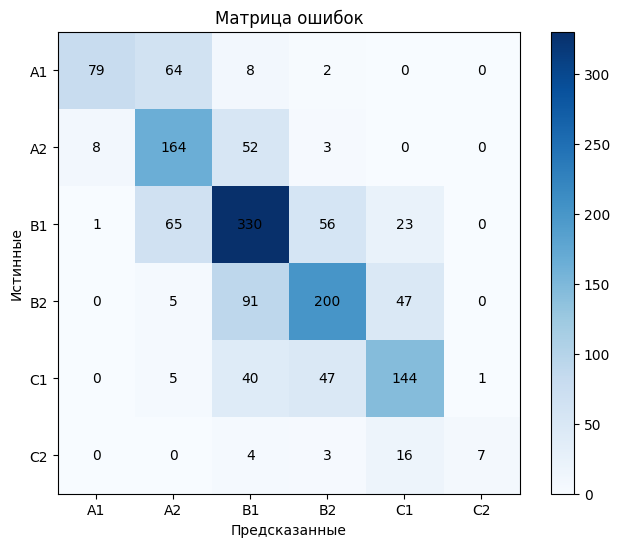

In [29]:
visualize_cm(true_labels, predictions)

# Температура 1.1

In [30]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_1_1.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.037800,0.947648
2,0.541500,1.026451
3,0.142100,1.432542


Обучение завершено за 383.17 секунд (0:06:23)


In [31]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6232
F1 Micro: 0.6232
F1 Macro: 0.5797
F1 Weighted: 0.6201
MAE: 0.4444
              precision    recall  f1-score   support

           1       0.90      0.46      0.61       153
           2       0.52      0.72      0.61       227
           3       0.61      0.71      0.66       475
           4       0.65      0.55      0.60       343
           5       0.65      0.62      0.63       237
           6       1.00      0.23      0.38        30

    accuracy                           0.62      1465
   macro avg       0.72      0.55      0.58      1465
weighted avg       0.65      0.62      0.62      1465



0.6232
0.6232
0.5797
0.6201
0.4444
383.17


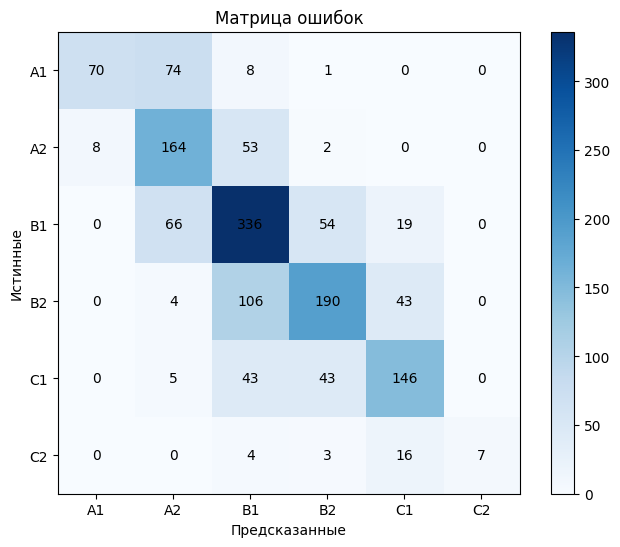

In [32]:
visualize_cm(true_labels, predictions)

# Температура 1.2

In [33]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_1_2.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.036600,0.937426
2,0.508800,1.006128
3,0.125100,1.472987


Обучение завершено за 376.36 секунд (0:06:16)


In [34]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6300
F1 Micro: 0.6300
F1 Macro: 0.5950
F1 Weighted: 0.6283
MAE: 0.4389
              precision    recall  f1-score   support

           1       0.89      0.52      0.65       153
           2       0.54      0.73      0.62       227
           3       0.63      0.69      0.66       475
           4       0.64      0.56      0.60       343
           5       0.63      0.63      0.63       237
           6       0.89      0.27      0.41        30

    accuracy                           0.63      1465
   macro avg       0.70      0.57      0.60      1465
weighted avg       0.65      0.63      0.63      1465



0.6300
0.6300
0.5950
0.6283
0.4389
376.36


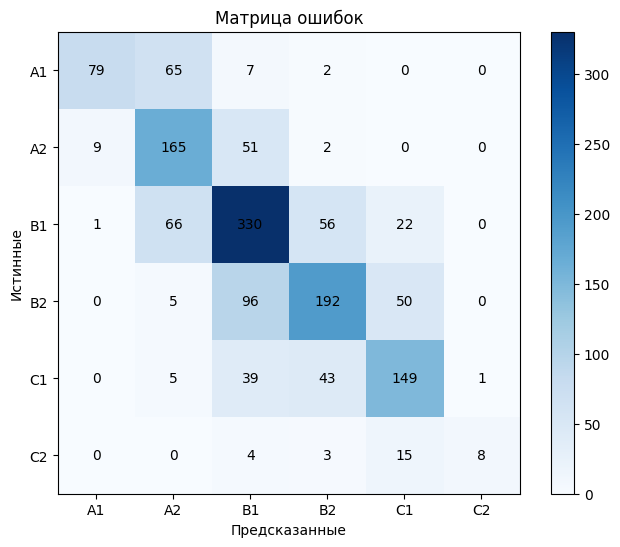

In [35]:
visualize_cm(true_labels, predictions)

# Температура 1.3

In [36]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_1_3.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.031600,0.934433
2,0.508600,1.040885
3,0.136500,1.444008


Обучение завершено за 385.27 секунд (0:06:25)


In [37]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6341
F1 Micro: 0.6341
F1 Macro: 0.5848
F1 Weighted: 0.6314
MAE: 0.4362
              precision    recall  f1-score   support

           1       0.88      0.52      0.66       153
           2       0.54      0.75      0.63       227
           3       0.63      0.70      0.66       475
           4       0.65      0.56      0.60       343
           5       0.64      0.63      0.63       237
           6       0.86      0.20      0.32        30

    accuracy                           0.63      1465
   macro avg       0.70      0.56      0.58      1465
weighted avg       0.65      0.63      0.63      1465



0.6341
0.6341
0.5848
0.6314
0.4362
385.27


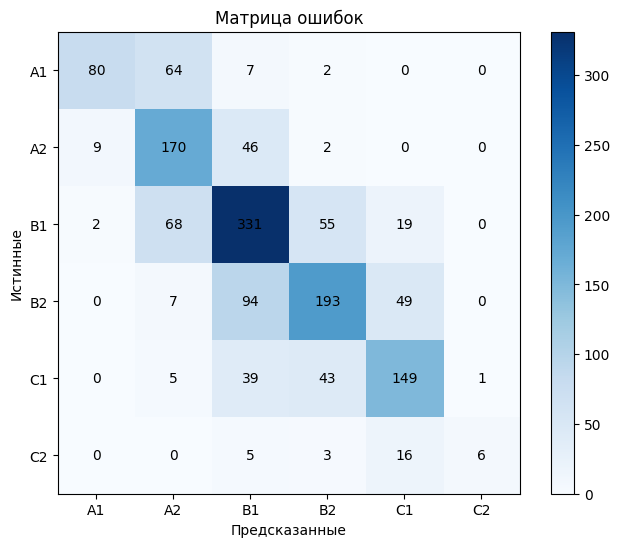

In [38]:
visualize_cm(true_labels, predictions)

# Температура 1.4

In [39]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_1_4.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.040200,0.947920
2,0.518800,1.034849
3,0.121900,1.448002


Обучение завершено за 381.31 секунд (0:06:21)


In [40]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6191
F1 Micro: 0.6191
F1 Macro: 0.5696
F1 Weighted: 0.6158
MAE: 0.4553
              precision    recall  f1-score   support

           1       0.89      0.48      0.62       153
           2       0.52      0.77      0.62       227
           3       0.62      0.68      0.65       475
           4       0.63      0.57      0.60       343
           5       0.65      0.56      0.60       237
           6       0.86      0.20      0.32        30

    accuracy                           0.62      1465
   macro avg       0.69      0.54      0.57      1465
weighted avg       0.64      0.62      0.62      1465



0.6191
0.6191
0.5696
0.6158
0.4553
381.31


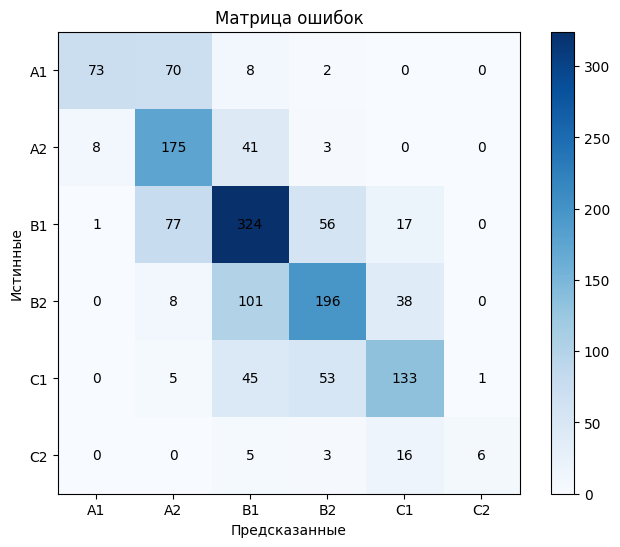

In [41]:
visualize_cm(true_labels, predictions)

# Температура 1.5

In [42]:
c2 = pd.read_csv('c2_augmented_11_llama3_temp_1_5.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.037200,0.931470
2,0.524900,1.012452
3,0.150400,1.414165


Обучение завершено за 383.14 секунд (0:06:23)


In [43]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6396
F1 Micro: 0.6396
F1 Macro: 0.5991
F1 Weighted: 0.6377
MAE: 0.4307
              precision    recall  f1-score   support

           1       0.89      0.54      0.67       153
           2       0.56      0.73      0.63       227
           3       0.64      0.70      0.67       475
           4       0.63      0.59      0.61       343
           5       0.65      0.62      0.64       237
           6       1.00      0.23      0.38        30

    accuracy                           0.64      1465
   macro avg       0.73      0.57      0.60      1465
weighted avg       0.66      0.64      0.64      1465



0.6396
0.6396
0.5991
0.6377
0.4307
383.14


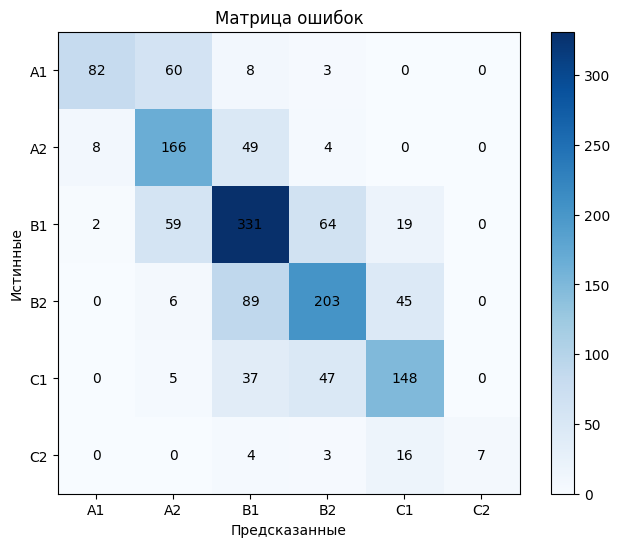

In [44]:
visualize_cm(true_labels, predictions)